In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 3000

x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)
X = np.column_stack((x1, x2))
y = (x1**2 + x2**2 > 1.5).astype(int).reshape(-1,1)

indices = np.random.permutation(N)
X = X[indices]
y = y[indices]

train_end = int(0.7 * N)
val_end = int(0.85 * N)

In [3]:
X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print(X_train.shape, X_val.shape, X_test.shape)

(2100, 2) (450, 2) (450, 2)


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def d_sigmoid(a):
    return a * (1 - a)

def d_relu(z):
    return (z > 0).astype(float)

def init_network(layers):
    params = {}
    for l in range(1, len(layers)):
        params["W"+str(l)] = np.random.randn(layers[l-1], layers[l]) * 0.1
        params["b"+str(l)] = np.zeros((1, layers[l]))
    return params

In [5]:
def forward(X, params, activation):
    cache = {}
    A = X
    L = len(params)//2

    for l in range(1, L):
        Z = A @ params["W"+str(l)] + params["b"+str(l)]

        if activation == "sigmoid":
            A = sigmoid(Z)
        else:
            A = relu(Z)

        cache["A"+str(l)] = A
        cache["Z"+str(l)] = Z

    ZL = A @ params["W"+str(L)] + params["b"+str(L)]
    AL = sigmoid(ZL)

    cache["A"+str(L)] = AL
    cache["Z"+str(L)] = ZL

    return AL, cache

In [6]:
def compute_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-8, 1-1e-8)
    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

def compute_accuracy(y_hat, y):
    y_pred = (y_hat >= 0.5).astype(int)
    return np.mean(y_pred == y)

In [7]:
def backward(X, y, params, cache, activation):
    grads = {}
    m = X.shape[0]
    L = len(params)//2

    dZ = cache["A"+str(L)] - y

    for l in reversed(range(1, L+1)):

        if l == 1:
            A_prev = X
        else:
            A_prev = cache["A"+str(l-1)]

        grads["dW"+str(l)] = (A_prev.T @ dZ) / m
        grads["db"+str(l)] = np.sum(dZ, axis=0, keepdims=True) / m

        if l > 1:
            dA_prev = dZ @ params["W"+str(l)].T

            if activation == "sigmoid":
                dZ = dA_prev * d_sigmoid(cache["A"+str(l-1)])
            else:
                dZ = dA_prev * d_relu(cache["Z"+str(l-1)])

    return grads

In [8]:
def update_sgd(params, grads, lr):
    for key in params:
        params[key] -= lr * grads["d"+key]
    return params


def update_momentum(params, grads, velocity, lr, beta=0.9):
    for key in params:
        velocity[key] = beta * velocity[key] + lr * grads["d"+key]
        params[key] -= velocity[key]
    return params, velocity

In [10]:
def train(layers, activation="relu", optimizer="sgd", epochs=120, lr=0.05):

    params = init_network(layers)
    L = len(layers)-1

    velocity = {}
    if optimizer == "momentum":
        for key in params:
            velocity[key] = np.zeros_like(params[key])

    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []
    grad_norm_list = []

    for epoch in range(epochs):

        y_hat, cache = forward(X_train, params, activation)

        loss = compute_loss(y_hat, y_train)
        acc = compute_accuracy(y_hat, y_train)

        grads = backward(X_train, y_train, params, cache, activation)

        grad_norm = 0
        for l in range(1, L+1):
            grad_norm += np.sum(grads["dW"+str(l)]**2)
        grad_norm = np.sqrt(grad_norm)

        if optimizer == "sgd":
            params = update_sgd(params, grads, lr)
        else:
            params, velocity = update_momentum(params, grads, velocity, lr)

        val_hat, _ = forward(X_val, params, activation)
        val_loss = compute_loss(val_hat, y_val)
        val_acc = compute_accuracy(val_hat, y_val)

        train_loss_list.append(loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(acc)
        val_acc_list.append(val_acc)
        grad_norm_list.append(grad_norm)

    test_hat, _ = forward(X_test, params, activation)

    print("Train Acc:", train_acc_list[-1])
    print("Val Acc:", val_acc_list[-1])
    print("Test Acc:", compute_accuracy(test_hat, y_test))
    print("Train Loss:", train_loss_list[-1])
    print("Val Loss:", val_loss_list[-1])
    print("Test Loss:", compute_loss(test_hat, y_test))
    plt.figure()
    plt.plot(train_loss_list)
    plt.plot(val_loss_list)
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(train_acc_list)
    plt.plot(val_acc_list)
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(grad_norm_list)
    plt.title("Gradient Norm")
    plt.show()

    return params

Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6073249269471259
Val Loss: 0.5699043371704073
Test Loss: 0.5763512692198166


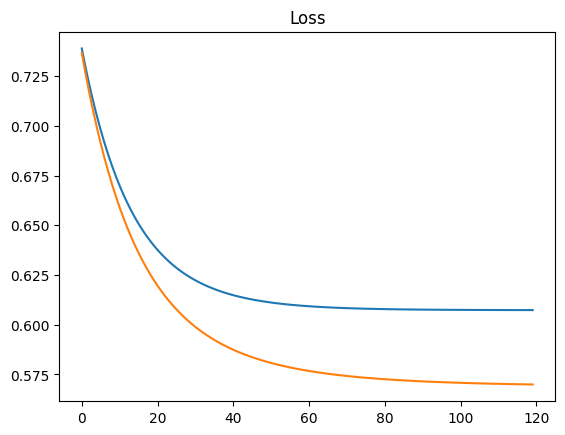

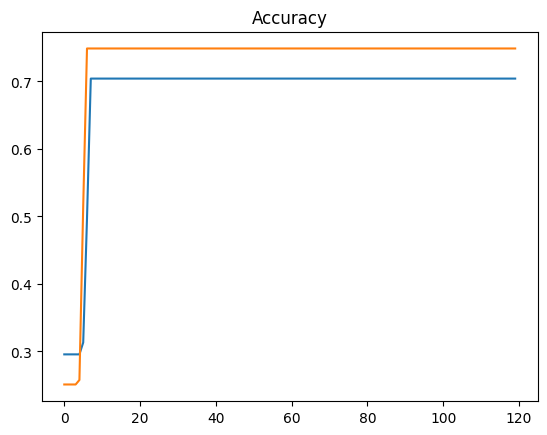

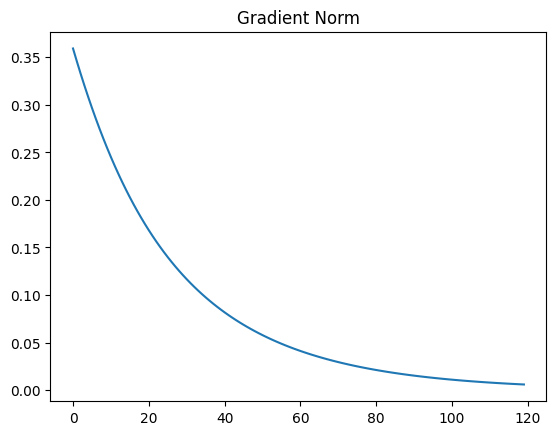

Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071961040504157
Val Loss: 0.5688411368887728
Test Loss: 0.5764847418383776


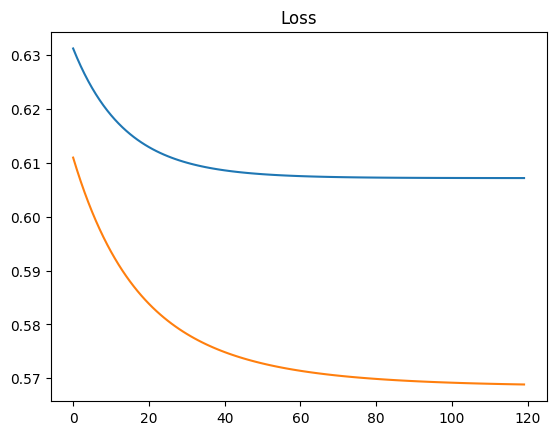

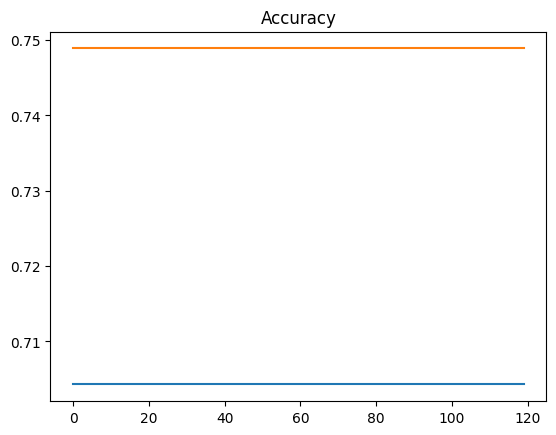

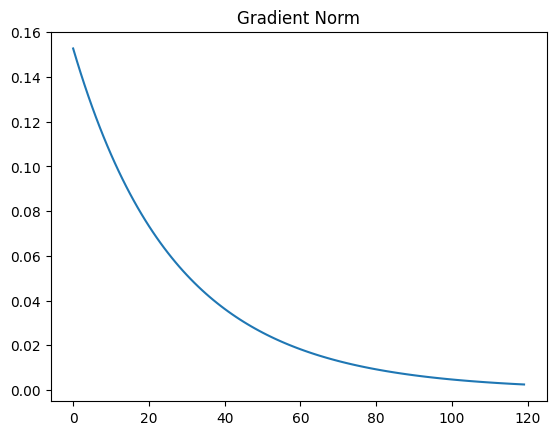

{'W1': array([[-0.18296818,  0.0615967 ,  0.10371814, -0.09104867, -0.02440284,
          0.02947193,  0.06932176, -0.20276773],
        [-0.08860402, -0.03325794,  0.07031402,  0.24984305, -0.02280057,
         -0.14069775,  0.04022681,  0.13209958]]),
 'b1': array([[-3.34993642e-12,  1.52439150e-12, -3.68067415e-12,
          9.12692197e-13,  4.55782776e-12, -2.57551261e-12,
          2.03321696e-12,  2.34864907e-12]]),
 'W2': array([[ 0.01080141, -0.09066485,  0.09579939,  0.06635456, -0.10260808,
          0.03814256,  0.09972656,  0.118189  ],
        [-0.0066449 , -0.03580794,  0.12272738, -0.12101605,  0.04385793,
         -0.13700266,  0.10653763, -0.02580455],
        [ 0.12685832,  0.04914128, -0.12232202,  0.14246277,  0.15512453,
          0.08822865, -0.07615879, -0.0306014 ],
        [ 0.01454272, -0.07037104,  0.16923466,  0.01443265, -0.2703348 ,
          0.03393558, -0.03481574, -0.00749266],
        [-0.03686194,  0.08070464,  0.11196878,  0.02830532, -0.03393112,
  

In [11]:
layers_2 = [2, 8, 1]
train(layers_2, activation="sigmoid", optimizer="sgd")

layers_10 = [2] + [8]*9 + [1]
train(layers_10, activation="sigmoid", optimizer="sgd")

LAYERS 2
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6073249269471259
Val Loss: 0.5699043371704073
Test Loss: 0.5763512692198166

{'W1': array([[-0.02673854,  0.0979545 , -0.10778632, -0.06117151, -0.14915064,
         -0.09931982, -0.11659229,  0.09849075],
        [-0.06969076,  0.01257178, -0.03787004, -0.12680634, -0.01664728,
          0.06007554, -0.12059226,  0.08097133]]),
 'b1': array([[ 2.75190937e-05,  3.18004199e-03,  1.17830910e-02,
          1.53101367e-03,  7.38833798e-03,  4.54066220e-03,
          8.08896373e-03, -1.30590986e-02]]),
 'W2': array([[ 0.08918581],
        [ 0.12735074],
        [ 0.22686447],
        [ 0.10749476],
        [ 0.1769425 ],
        [ 0.14216387],
        [ 0.18645563],
        [-0.06305823]]),
 'b2': array([[0.34916311]])}

LAYERS 10
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071961040504157
Val Loss: 0.5688411368887728
Test Loss: 0.5764847418383776